# AI Chip ASP Regression — Experiment Tracking

**Problem**: predict an AI accelerator's estimated average selling price (ASP, in USD) from its
specs (memory, FP16 throughput, TDP, vendor, launch year), using `datasets/raw/ai_chip_market.csv`.

This notebook documents the data-cleaning decisions, compares several regressors with
cross-validated metrics, tracks every run in MLflow, and justifies the model shipped in
`src/train.py` / `main.py`.

In [1]:
import os
from pathlib import Path

# Jupyter's working directory is wherever it was launched from, but this
# notebook's imports (metadata.py) and paths (datasets/raw/...) are relative
# to the project root, not notebooks/. Walk up until metadata.py is found.
while not (Path.cwd() / "metadata.py").exists():
    os.chdir("..")

In [2]:
import warnings

import matplotlib.pyplot as plt
import mlflow
import pandas as pd
from mlflow.models import infer_signature
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_score

from metadata import (
    CV_FOLDS,
    CV_REPEATS,
    MODEL_PARAMS,
    RANDOM_STATE,
    RAW_DATASET_FILE,
    TARGET_COLUMN,
)
from src.load import load_data
from src.transform import Transformer

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 120)

## 1. Load the raw data

In [3]:
raw_df = load_data(RAW_DATASET_FILE)
print(raw_df.shape)
raw_df.head()

(120, 11)


,year,chip_name,vendor,launch_date,memory_gb,fp16_tflops,tdp_watts,estimated_shipments_units,estimated_asp_usd,estimated_revenue_usd_m,description
0,2020,NVIDIA V100,NVIDIA,2017-05-10,32,100,300,6128,15000,91.9,Volta data center GPU
1,2021,NVIDIA V100,NVIDIA,2017-05-10,32,100,300,2719,15000,40.8,Volta data center GPU
2,2022,NVIDIA V100,NVIDIA,2017-05-10,32,100,300,3098,15000,46.5,Volta data center GPU
3,2023,NVIDIA V100,NVIDIA,2017-05-10,32,100,300,2572,15000,38.6,Volta data center GPU
4,2024,NVIDIA V100,NVIDIA,2017-05-10,32,100,300,3437,15000,51.6,Volta data center GPU


## 2. Data quality issues found during EDA

Three things stood out while exploring `ai_chip_market.csv` that directly shaped the
transformation logic in `src/transform.py`:

1. **Each chip is repeated once per year it stayed on the market** — specs and ASP are
   constant per `chip_name` across years, so a random row-level train/test split would put
   the same chip's specs in both train and test (leakage). Fix: collapse to one row per chip.
2. **Two chips report `estimated_asp_usd == 0`** (Google TPU v5p, TPU v6 Trillium) — these are
   cloud-only parts with undisclosed public pricing, not free chips. Fix: drop rows with a
   non-positive target.
3. **One chip (Cerebras WSE-3) reports `memory_gb == 0` and `estimated_asp_usd == 2,500,000`** —
   it's a wafer-scale *system* price, not a per-chip ASP, and as a single point in a 30-row
   dataset it would dominate any loss function. Fix: drop rows with `memory_gb == 0`.

In [4]:
chip_year_span = raw_df.groupby("chip_name")["year"].nunique()
print("chips with >1 row (repeated across years):", (chip_year_span > 1).sum(), "/", len(chip_year_span))

quality_flags = raw_df[(raw_df["estimated_asp_usd"] <= 0) | (raw_df["memory_gb"] == 0)]
quality_flags[["chip_name", "vendor", "memory_gb", "estimated_asp_usd", "description"]].drop_duplicates("chip_name")

chips with >1 row (repeated across years): 30 / 30


,chip_name,vendor,memory_gb,estimated_asp_usd,description
65,Google TPU v5p,Google,96,0,Production TPU
69,Google TPU v6 Trillium,Google,32,0,6th gen TPU
82,Cerebras WSE-3,Cerebras,0,2500000,Wafer-scale 4 trillion transistors


## 3. Transform: dedupe + drop leakage/invalid rows + one-hot encode

`Transformer.fit_transform` (see `src/transform.py`) applies all three fixes above, drops
columns that are either identifiers/free text or downstream of the target
(`estimated_revenue_usd_m` and `estimated_shipments_units` are priced off ASP, so keeping
them would leak the target), and one-hot encodes `vendor`.

In [5]:
transformer = Transformer()
model_df = transformer.fit_transform(raw_df, target_column=TARGET_COLUMN)
print(model_df.shape)
model_df.head()

(27, 14)


,year,memory_gb,fp16_tflops,tdp_watts,estimated_asp_usd,vendor_AWS,vendor_Apple,vendor_Cambricon,vendor_Google,vendor_Groq,vendor_Huawei,vendor_NVIDIA,vendor_SambaNova,vendor_Tenstorrent
0,2026,64,800,450,20000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2026,32,100,300,15000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2026,141,989,700,32000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2026,40,312,400,15000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2026,32,256,310,15000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## 4. Why repeated K-fold cross-validation

With only ~27 independent samples left after cleaning, a *single* K-fold split is highly
sensitive to the random seed used to build the folds — a test fold that happens to contain
an expensive data-center chip swings the score wildly. The cell below reproduces that
instability directly: same model, same data, only the CV seed changes.

In [6]:
X = model_df.drop(columns=[TARGET_COLUMN])
y = model_df[TARGET_COLUMN]

seed_sensitivity = []
for seed in [0, 1, 42, 123]:
    cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)
    r2 = cross_val_score(
        GradientBoostingRegressor(max_depth=2, n_estimators=100, random_state=42),
        X, y, cv=cv, scoring="r2",
    ).mean()
    seed_sensitivity.append({"cv_seed": seed, "r2": r2})

pd.DataFrame(seed_sensitivity)

,cv_seed,r2
0,0,-2.053929
1,1,0.594841
2,42,0.812888
3,123,0.588550


A single split's R² ranges from strongly negative to >0.8 depending only on the CV seed —
not a usable model-selection signal on its own. **`RepeatedKFold` (5 splits × 20 repeats)**
averages this noise out and is what both this comparison and `src/train.py` use from here on.
MAE/RMSE are also reported because they're far less volatile than R² at this sample size.

## 5. Compare candidate models with MLflow tracking

Four regressors, increasing in complexity: a plain linear baseline, a regularized linear
model, and two tree ensembles. Each is cross-validated with the same `RepeatedKFold`, then
refit on all the data and logged to MLflow as its own run (params, CV metrics, and the
fitted model artifact).

In [7]:
mlflow.set_experiment("ai-chip-asp-regression")

candidate_models = {
    "linear-regression": LinearRegression(),
    "ridge-regression": Ridge(alpha=10, random_state=RANDOM_STATE),
    "random-forest": RandomForestRegressor(n_estimators=100, max_depth=4, random_state=RANDOM_STATE),
    "gradient-boosting": GradientBoostingRegressor(n_estimators=100, max_depth=2, random_state=RANDOM_STATE),
}

cv = RepeatedKFold(n_splits=CV_FOLDS, n_repeats=CV_REPEATS, random_state=RANDOM_STATE)
comparison_rows = []

for run_name, model in candidate_models.items():
    neg_mae = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_absolute_error")
    neg_rmse = cross_val_score(model, X, y, cv=cv, scoring="neg_root_mean_squared_error")
    r2 = cross_val_score(model, X, y, cv=cv, scoring="r2")

    metrics = {
        "mae": float(-neg_mae.mean()),
        "rmse": float(-neg_rmse.mean()),
        "r2_mean": float(r2.mean()),
        "r2_std": float(r2.std()),
    }

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({**model.get_params(), "cv_folds": CV_FOLDS, "cv_repeats": CV_REPEATS})
        mlflow.log_metrics(metrics)
        mlflow.set_tag("model_family", type(model).__name__)

        model.fit(X, y)
        signature = infer_signature(X, model.predict(X))
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model",
            signature=signature,
            input_example=X.head(2),
        )

    comparison_rows.append({"model": run_name, **metrics})

results_df = pd.DataFrame(comparison_rows).sort_values("mae")
results_df

2026/06/24 23:25:40 INFO mlflow.tracking.fluent: Experiment with name 'ai-chip-asp-regression' does not exist. Creating a new experiment.


,model,mae,rmse,r2_mean,r2_std
3,gradient-boosting,3200.694803,5135.758960,0.080638,2.340493
2,random-forest,3887.905016,5876.122410,-0.367283,4.605215
1,ridge-regression,6697.161199,10628.477650,-24.952445,151.003750
0,linear-regression,7042.655354,9843.614393,-4.728555,18.372930


## 6. Chosen model & justification

**`gradient-boosting` (max_depth=2, n_estimators=100)** has the lowest MAE/RMSE and the
least-negative, least-volatile R² of the four. The linear models perform poorly (often
negative R²) because ASP doesn't scale additively with specs — e.g. very high TDP/throughput
parts command disproportionately higher prices, which a depth-2 tree ensemble captures
without the model being "overly complex" (shallow trees, no extra feature engineering).
This is the model trained by `src/train.py` and shipped via `main.py` / the CD pipeline.

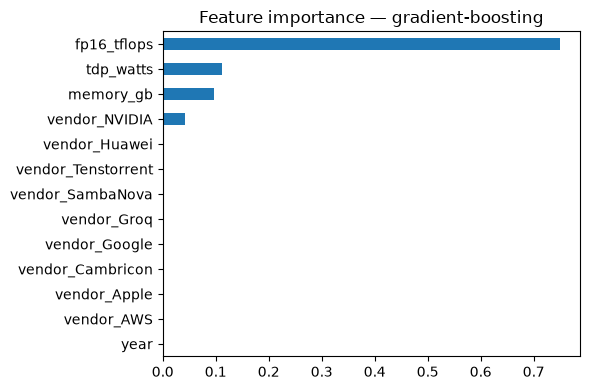

In [8]:
final_model = GradientBoostingRegressor(**MODEL_PARAMS)
final_model.fit(X, y)

importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind="barh", figsize=(6, 4), title="Feature importance — gradient-boosting")
plt.tight_layout()
plt.show()

## 7. Viewing the runs in the MLflow UI

Run `mlflow ui` from the project root (it reads the local `mlruns/` folder created by this
notebook) and open http://127.0.0.1:5000 to compare the four runs side by side — this is
where the screenshots for the project report come from.